In [1]:
print("hi")

hi


In [4]:
%pip install pandas

  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB 435.7 kB/s eta 0:00:23
   ---------------------------------------- 0.0/9.9 MB 326.8 kB/s eta 0:00:31
   ---------------------------------------- 0.1/9.9 MB 465.5 kB/s eta 0:00:22
   ---------------------------------------- 0.1/9.9 MB 465.5 kB/s eta 0:00:22
   ---------------------------------------- 0.1/9.9 MB 401.6 kB/s eta 0:00:25
   ---------------------------------------- 0.1/9.9 MB 401.6 kB/s eta 0:00:25
   ---------------------------------------- 0.1/9.9 MB 401.6 kB/s eta 0:00:25
   ---------------------------------------- 0.1/9.9 MB 401.6 kB/s eta 0:00:25
    --------------------------------------- 0.2/9.9 MB 436.8 kB/s eta 0:00:23
    --------------------------------------- 0.2/9.9 MB 436.8 kB/s eta 0:00:23
    --------------------------------------- 0.2/9.9 MB 401.2 kB/s eta 0:00:25
    -


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Transformed GPS Data (First 5 Rows):
             timestamp       x_m        y_m
0  1703098100378834176  0.000000   0.000000
1  1703098100587210240  0.894130  -3.926293
2  1703098100795555072  2.245108  -7.534237
3  1703098101003794944  3.976167 -10.781387
4  1703098101212150016  6.038385 -13.662158


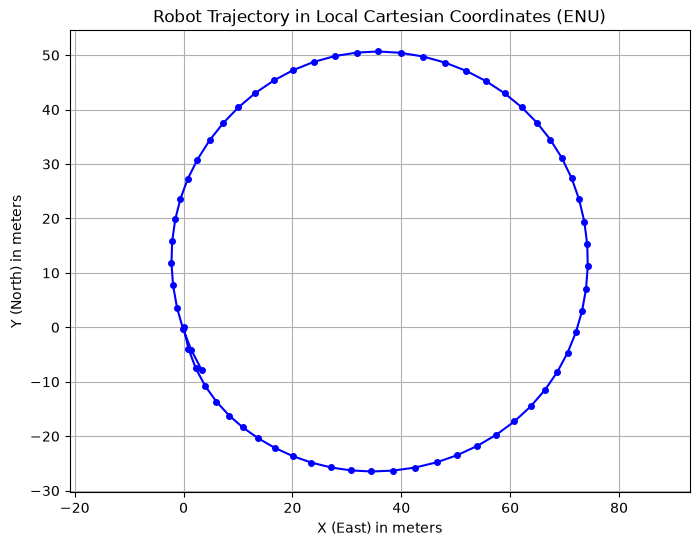

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def convert_gps_to_enu(file_path):
    # 1. Read the GPS data
    # The file contains: timestamp, lat, lon
    df_gps = pd.read_csv(file_path)
    
    # Clean column names just in case there are trailing spaces
    df_gps.columns = df_gps.columns.str.strip()

    # 2. Convert latitude and longitude from degrees to radians
    # np.deg2rad handles the conversion: (degrees * pi / 180)
    lat_rad = np.deg2rad(df_gps['lat'])
    lon_rad = np.deg2rad(df_gps['lon'])

    # 3. Set the constants
    # Earth radius converted from 6400 km to meters
    R = 6400 * 1000 

    # 4. Extract the origin point (lat_0, lon_0) from the first row
    lat_0 = lat_rad.iloc[0]
    lon_0 = lon_rad.iloc[0]

    # 5. Calculate Cartesian coordinates (ENU)
    # Applying the provided formulas
    df_gps['x_m'] = R * (lon_rad - lon_0) * np.cos(lat_0)
    df_gps['y_m'] = R * (lat_rad - lat_0)

    return df_gps

# --- Execution and Visualization ---

# Assuming your file is named 'gps.txt'
# Replace 'gps.txt' with the actual path if it's in a different directory
gps_data_transformed = convert_gps_to_enu('./data/gps.txt')

# Display the first few rows to verify the output
print("Transformed GPS Data (First 5 Rows):")
print(gps_data_transformed[['timestamp', 'x_m', 'y_m']].head())
gps_data_transformed.to_csv('./data/gps_transformed.csv', index=False)

# Visualizing the path to validate the output
plt.figure(figsize=(8, 6))
plt.plot(gps_data_transformed['x_m'], gps_data_transformed['y_m'], marker='o', markersize=4, linestyle='-', color='b')
plt.title('Robot Trajectory in Local Cartesian Coordinates (ENU)')
plt.xlabel('X (East) in meters')
plt.ylabel('Y (North) in meters')
plt.grid(True)
plt.axis('equal') # Ensures scale is equal on both axes
plt.show()